In [2]:
import torch
from scipy.sparse import coo_matrix
from torch_geometric.data import Data
import networkx as nx
from torch_geometric.utils import to_networkx

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

/home/nii/anaconda3/envs/conda_sgu_2026_fer_graph/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
first_row = pd.read_csv("fer13-split/train.csv", nrows=1)
pixel_str = first_row.loc[0, "pixels"]   # "70 80 82 ..."

img_array = np.fromstring(pixel_str, sep=" ", dtype=np.uint8).reshape(48, 48)

# 1. Image &rarr; Graph

Tóm tắt:
- Chuyển image &rarr; graph, có 2304 node
- Có 3 mảng cần quan tâm: 
    + 2 mảng danh sách cạnh
    + 1 mảng lưu giá trị của cạnh (chênh lệch độ sáng)

In [4]:
# Bước 1: Tạo node features (intensity của mỗi pixel)

H, W = 48, 48   # N = 2304 nodes
img = img_array.reshape(-1)    # node features: shape (2304,)

# Bước 2: Xây edge list (4 chiều + 4 đường chéo)
# Thay vì lưu ma trận kề -> lưu edge list
rows, cols = [], []
edge_weights = [] # lưu chênh lệch sáng tối giữa pixel trung tâm với 8 cái kề nó

for r in range(H):
  for c in range(W):
    i = r * W + c           # node id của pixel (r,c)

    for dr, dc in [(-1,0),(1,0),(0,-1),(0,1),(-1,-1),(-1,1),(1,-1),(1,1)]:
      nr, nc = r+dr, c+dc
      if 0 <= nr < H and 0 <= nc < W:
        j = nr * W + nc     # node id của láng giềng

        rows.append(i)
        cols.append(j)

        # tính chênh lệch 
        diff = float(img[i]) - float(img[j])
        edge_weights.append(diff)


# Bước 3: Sparse adjacency matrix (không lưu dense!)
# data = np.ones(len(rows))
# A = coo_matrix((data, (rows, cols)), shape=(H*W, H*W))

# PyTorch Geometric:
edge_index = torch.tensor([rows, cols], dtype=torch.long)
edge_attr = torch.tensor(edge_weights, dtype=torch.float).unsqueeze(1) # (edge, 1 feature)
x = torch.tensor(img, dtype=torch.float).unsqueeze(1)

graph = Data(x=x, edge_index=edge_index, edge_attr=edge_attr)
graph_without_edge_weight = Data(x=x, edge_index=edge_index)


In [5]:
def plot_graph(graph):
        G_visual = to_networkx(graph, to_undirected=True)

        plt.figure(figsize=(8, 8))
        nx.draw(G_visual, 
                node_size=20, 
                node_color='blue', 
                edge_color='gray', 
                with_labels=False)
        plt.title("Mô hình đồ thị từ điểm ảnh")
        plt.show()

def plot_graph_grid(graph, H=48, W=48):
    G_visual = to_networkx(graph, to_undirected=True)
    
    # Tạo tọa độ Grid (lưới) cho từng node
    pos = {}
    for r in range(H):
        for c in range(W):
            node_id = r * W + c
            # Trục Y lấy âm (-r) để Node 0 (r=0) nằm ở trên cùng (giống hệ tọa độ ảnh)
            pos[node_id] = (c, -r) 
            
    plt.figure(figsize=(8, 8))
    nx.draw(G_visual, 
            pos=pos,               # <--- Thêm tham số pos vào đây
            node_size=10,          # (Nên chỉnh node nhỏ lại một chút vì lưới rất dày)
            node_color='blue', 
            edge_color='gray', 
            with_labels=False)
    plt.title("Mô hình đồ thị từ điểm ảnh (Dạng Lưới Cố Định)")
    plt.show()

def plot_graph_grid_with_weights(graph, H=48, W=48):
    # Quan trọng: truyền thêm tham số edge_attrs để NetworkX giữ lại thuộc tính này
    G_visual = to_networkx(graph, edge_attrs=['edge_attr'], to_undirected=False)
    
    # Kéo tọa độ lưới
    pos = {r * W + c: (c, -r) for r in range(H) for c in range(W)}
            
    plt.figure(figsize=(10, 8))
    
    # Kiểm tra xem đồ thị có truyền trọng số không
    if hasattr(graph, 'edge_attr') and graph.edge_attr is not None:
        # Trích xuất danh sách trọng số từ các cạnh trong NetworkX
        # Do edge_attr đang là mảng 1 phần tử [weight], ta lấy data['edge_attr'][0]
        weights = [data['edge_attr'][0] for u, v, data in G_visual.edges(data=True)]
        
        nx.draw(G_visual, 
                pos=pos,               
                node_size=5,           # Cho node thật nhỏ để nhìn rõ cạnh
                node_color='black', 
                edge_color=weights,            # <-- Đưa mảng trọng số vào màu sắc
                edge_cmap=plt.cm.coolwarm,     # <-- Dải màu: Xanh (âm) -> Trắng (0) -> Đỏ (dương)
                width=1.0,
                with_labels=False)
        
        # Thêm thanh chú thích màu (Colorbar)
        sm = plt.cm.ScalarMappable(cmap=plt.cm.coolwarm, 
                                   norm=plt.Normalize(vmin=min(weights), vmax=max(weights)))
        sm.set_array([])
        plt.colorbar(sm, label='Độ lệch sáng/tối (Edge Weight)', ax=plt.gca())
        plt.title("Đồ thị dạng lưới GÓC NHÌN TRỌNG SỐ (Edge Weights)")
        
    else:
        # Nếu đồ thị không có trọng số (graph_without_edge_weight)
        nx.draw(G_visual, pos=pos, node_size=10, node_color='blue', edge_color='gray', with_labels=False)
        plt.title("Đoạn đồ thị KHÔNG TRỌNG SỐ")

    plt.show()

def plot_graph_and_image(graph, img_array, H=48, W=48):
    # Trích xuất dữ liệu graph sang NetworkX
    G_visual = to_networkx(graph, edge_attrs=['edge_attr'], to_undirected=False)
    pos = {r * W + c: (c, -r) for r in range(H) for c in range(W)}
            
    # Tạo khung gồm 1 hàng và 2 cột
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    
    # --- BÊN TRÁI: Vẽ ảnh gốc ---
    axes[0].imshow(img_array, cmap='gray')
    axes[0].axis('off') # Ẩn viền và trục tọa độ
    axes[0].set_title("Ảnh Gốc", fontsize=14)

    # --- BÊN PHẢI: Vẽ đồ thị trọng số ---
    if hasattr(graph, 'edge_attr') and graph.edge_attr is not None:
        weights = [data['edge_attr'][0] for u, v, data in G_visual.edges(data=True)]
        
        # Lưu ý truyền thêm tham số ax=axes[1] để vẽ vào ô số 2
        nx.draw(G_visual, 
                ax=axes[1],
                pos=pos,               
                node_size=5,           
                node_color='black', 
                edge_color=weights,            
                edge_cmap=plt.cm.coolwarm,     
                width=1.0,
                with_labels=False)
        
        # Thiết lập thanh màu (colorbar)
        sm = plt.cm.ScalarMappable(cmap=plt.cm.coolwarm, 
                                   norm=plt.Normalize(vmin=min(weights), vmax=max(weights)))
        sm.set_array([])
        # Gắn colorbar vào riêng trục axes[1]
        fig.colorbar(sm, ax=axes[1], label='Độ lệch sáng/tối (Edge Weight)', shrink=0.8)
        axes[1].set_title("Đồ thị Trọng Số", fontsize=14)
        
    else:
        nx.draw(G_visual, ax=axes[1], pos=pos, node_size=10, node_color='blue', edge_color='gray', with_labels=False)
        axes[1].set_title("Đồ thị (Không trọng số)")

    plt.tight_layout()
    plt.show()


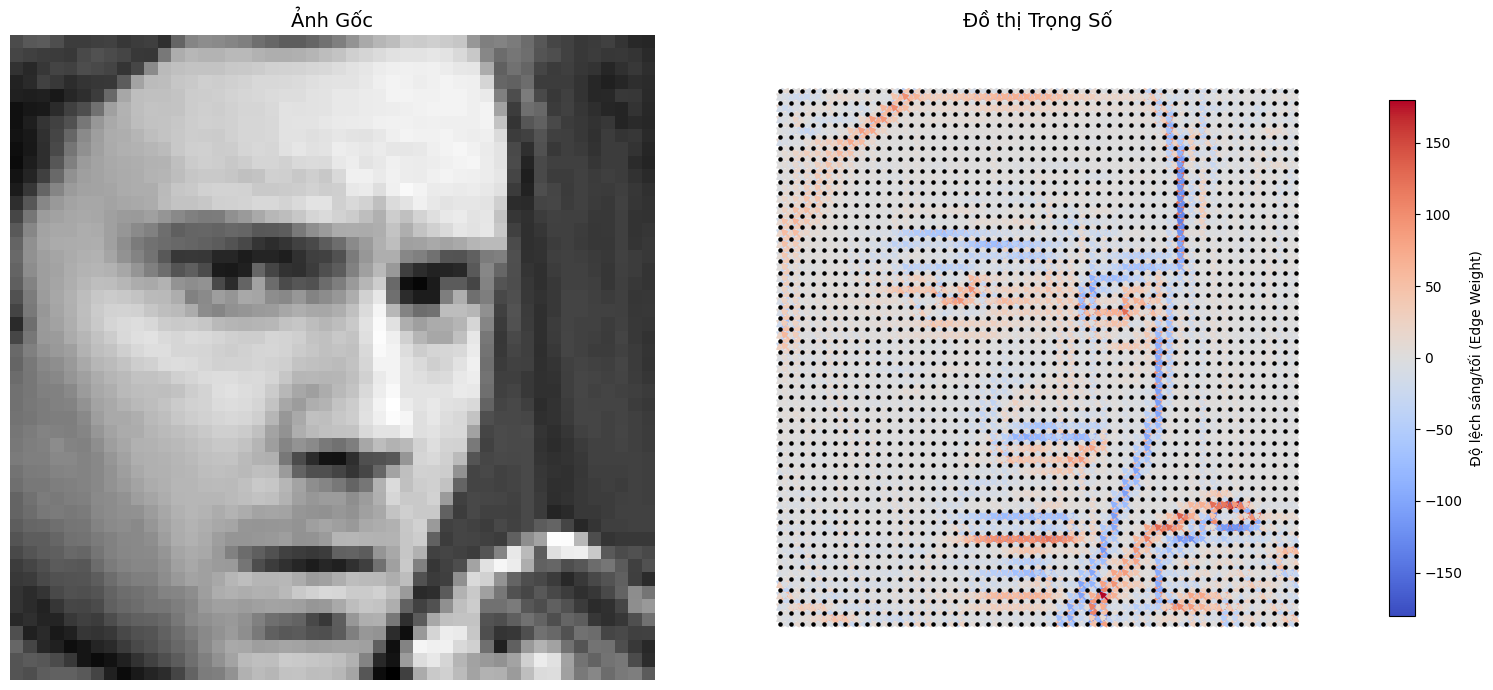

In [6]:
plot_graph_and_image(graph, img_array)


In [8]:
# Lấy danh sách hàng (node gốc) và cột (node đích)
rows = graph.edge_index[0]
cols = graph.edge_index[1]
weights = graph.edge_attr

print("--- DANH SÁCH 10 KẾT NỐI ĐẦU TIÊN ---")
for i in range(100):
    # Dùng .item() để chuyển từ định dạng Tensor của PyTorch sang số bình thường
    node_a = rows[i].item()
    node_b = cols[i].item()
    weight = weights[i].item()
    print(f"{node_a}  |{weight}|>  {node_b} ")

--- DANH SÁCH 10 KẾT NỐI ĐẦU TIÊN ---
0  |5.0|>  48 
0  |-10.0|>  1 
0  |9.0|>  49 
1  |19.0|>  49 
1  |10.0|>  0 
1  |-2.0|>  2 
1  |15.0|>  48 
1  |22.0|>  50 
2  |24.0|>  50 
2  |2.0|>  1 
2  |10.0|>  3 
2  |21.0|>  49 
2  |25.0|>  51 
3  |15.0|>  51 
3  |-10.0|>  2 
3  |14.0|>  4 
3  |14.0|>  50 
3  |16.0|>  52 
4  |2.0|>  52 
4  |-14.0|>  3 
4  |0.0|>  5 
4  |1.0|>  51 
4  |-11.0|>  53 
5  |-11.0|>  53 
5  |0.0|>  4 
5  |-2.0|>  6 
5  |2.0|>  52 
5  |-17.0|>  54 
6  |-15.0|>  54 
6  |2.0|>  5 
6  |-3.0|>  7 
6  |-9.0|>  53 
6  |-10.0|>  55 
7  |-7.0|>  55 
7  |3.0|>  6 
7  |9.0|>  8 
7  |-12.0|>  54 
7  |-2.0|>  56 
8  |-11.0|>  56 
8  |-9.0|>  7 
8  |-4.0|>  9 
8  |-16.0|>  55 
8  |-2.0|>  57 
9  |2.0|>  57 
9  |4.0|>  8 
9  |-2.0|>  10 
9  |-7.0|>  56 
9  |4.0|>  58 
10  |6.0|>  58 
10  |2.0|>  9 
10  |12.0|>  11 
10  |4.0|>  57 
10  |-45.0|>  59 
11  |-57.0|>  59 
11  |-12.0|>  10 
11  |-41.0|>  12 
11  |-6.0|>  58 
11  |-98.0|>  60 
12  |-57.0|>  60 
12  |41.0|>  11 
12  |-26.